# Курсовая работа студента Хомурар Д.В.

## Импорт и загрузка модулей

In [43]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.well import Well
from src.pipe import Pipe
from src.simulator import FieldSimulator
from src.compressor import DCS

# Загрузка данных
hw2_df = pd.read_csv('hw2_data.csv', sep = ';', index_col = 0)
my_data = hw2_df.iloc[10]
interp_df = pd.read_csv('interp_data.csv', sep = ';')

## 1. PVT-модель

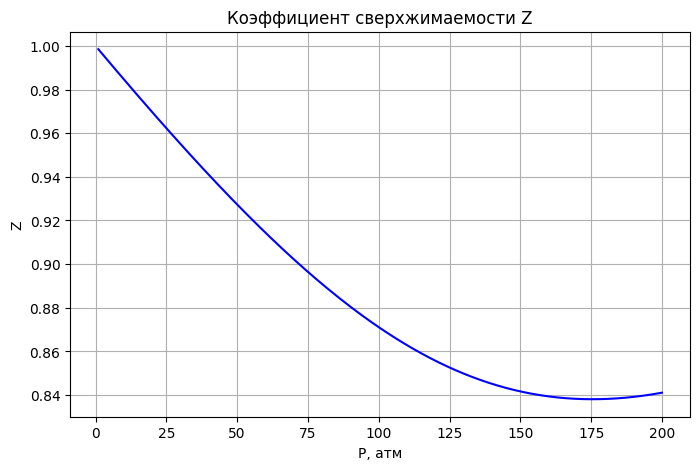

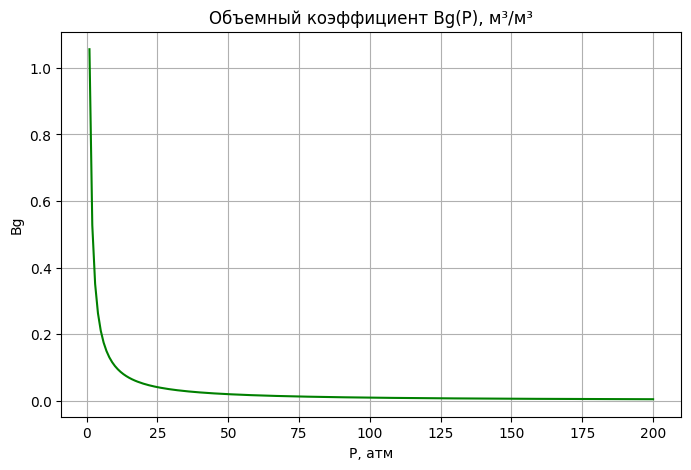

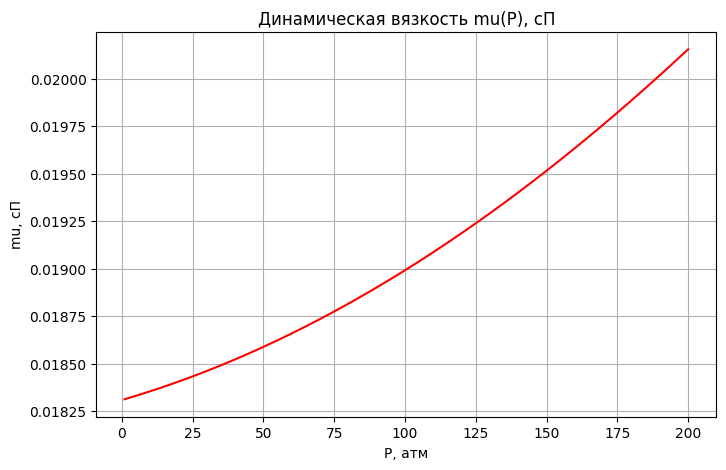

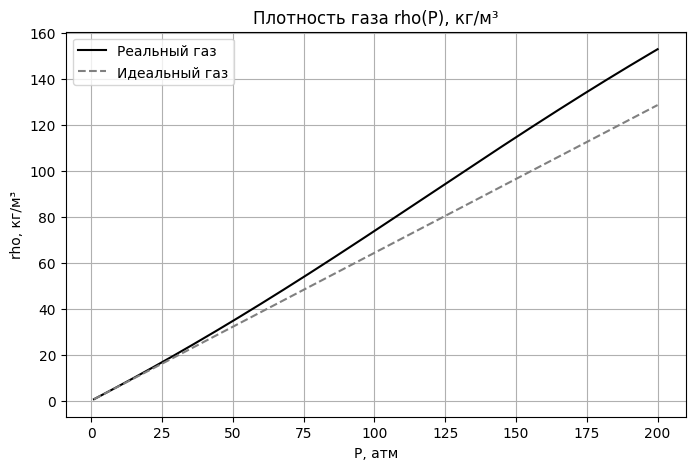

In [44]:
# Инициализация PVT-модели
fluid = Fluid(
    rho_c = my_data['rho_c, kg/m3'],
    xa = my_data['xa, mol. %'],
    xy = my_data['xy, mol. %'],
    T = 310,
    data = interp_df
)
# Графики Z, Bg, mu в диапазоне 1–200 атм и сравнение плотностей
P_range = np.linspace(1, 200, 200)
z_range = [fluid.get_z(i) for i in P_range]
bg_range = [fluid.get_bg(i) for i in P_range]
mu_range = [fluid.get_mu(i) for i in P_range]
rho_range = [fluid.get_rho(i) for i in P_range]
# Расчет плотности идеального газа (Z = 1)
R, T = 8.314, 310
rho_ideal = [(i * 101325 * fluid.M) / (R * T) for i in P_range]
# Построение графиков
# Расчёт коэффициента сверхжимаемости Z
plt.figure(figsize = (8,5))
plt.plot(P_range, z_range, color = 'blue')
plt.title('Коэффициент сверхжимаемости Z')
plt.xlabel('P, атм')
plt.ylabel('Z')
plt.grid(True)

plt.show()

# Объёмный коэффициент Bg
plt.figure(figsize = (8,5))
plt.plot(P_range, bg_range, color = 'green')
plt.title('Объемный коэффициент Bg(P), м³/м³')
plt.xlabel('P, атм')
plt.ylabel('Bg')
plt.grid(True)

plt.show()

# Динамическая вязкость mu
plt.figure(figsize = (8,5))
plt.plot(P_range, mu_range, color = 'red')
plt.title('Динамическая вязкость mu(P), сП')
plt.xlabel('P, атм')
plt.ylabel('mu, сП')
plt.grid(True)

plt.show()

# Плотность газа rho: реальный vs идеальный
plt.figure(figsize = (8,5))
plt.plot(P_range, rho_range, label = 'Реальный газ', color = 'black')
plt.plot(P_range, rho_ideal, '--', label = 'Идеальный газ', color = 'gray')
plt.title('Плотность газа rho(P), кг/м³')
plt.xlabel('P, атм')
plt.ylabel('rho, кг/м³')
plt.legend()
plt.grid(True)

plt.show()

## 2. Модель пласта

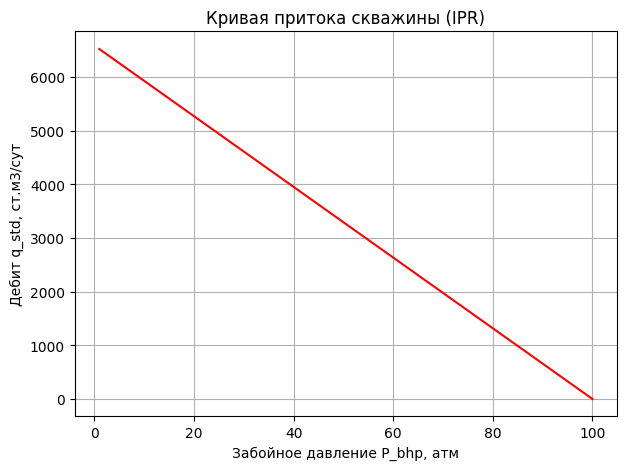

In [45]:
# Инициализация пласта
resprops = ResProps(P = 100, V = math.pi * 500**2 * 25, T = 310)
reservoir = Reservoir(ResProps = resprops, Fluid = fluid)
# Построение кривой IPR для одной скважины при P_res = 100
well_1 = Well(k = 50, h = 25, re = 500, rw = 0.1, fluid = fluid)
P_bhp_range = np.linspace(1, 100, 100)
q_ipr = [well_1.q(100, i) for i in P_bhp_range]

plt.figure(figsize = (7, 5))
plt.plot(P_bhp_range, q_ipr, color = 'red')
plt.title('Кривая притока скважины (IPR)')
plt.xlabel('Забойное давление P_bhp, атм')
plt.ylabel('Дебит q_std, ст.м3/сут')
plt.grid(True)

plt.show()

## 3. Гидравлика

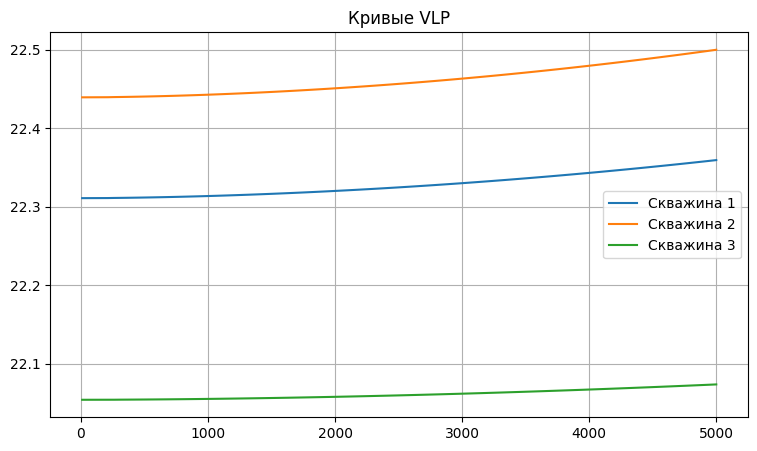

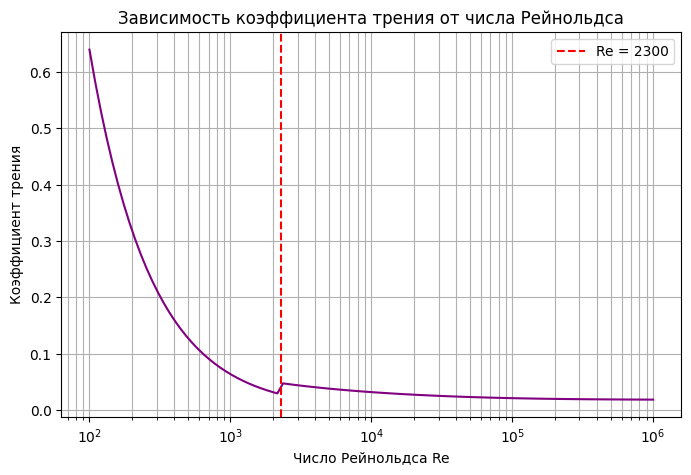

In [46]:
# Создание системы труб
pipes = [
    Pipe(2000, 0.062, 0.000046, fluid, 1800),
    Pipe(2500, 0.062, 0.000046, fluid, 1900),
    Pipe(1800, 0.073, 0.000046, fluid, 1600),
    Pipe(5000, 0.200, 0.000046, fluid, 0)
]
# Построение кривой VLP трёх скважин
q_vlp_range = np.linspace(10, 5000, 100)

plt.figure(figsize = (9, 5))
for i in range(3):
    P_bhp_vlp = [20 + (pipes[i].dP(20, q).dP) for q in q_vlp_range]
    plt.plot(q_vlp_range, P_bhp_vlp, label = f'Скважина {i+1}')
plt.title('Кривые VLP')
plt.legend()
plt.grid(True)

plt.show()

# Построение графика зависимости коэффициента трения от числа Рейнольдса
pipe_1 = pipes[0]
Re_range = np.logspace(2, 6, 100)
lambda_range = [pipe_1.get_lambda(i) for i in Re_range]

plt.figure(figsize = (8, 5))
plt.plot(Re_range, lambda_range, color = 'purple')
plt.xscale('log')
plt.title('Зависимость коэффициента трения от числа Рейнольдса')
plt.xlabel('Число Рейнольдса Re')
plt.ylabel('Коэффициент трения')
plt.axvline(2300, color = 'red', linestyle='--', label = 'Re = 2300')
plt.grid(True, which = "both", ls = "-")
plt.legend()

plt.show()

## 4. Рабочая точка

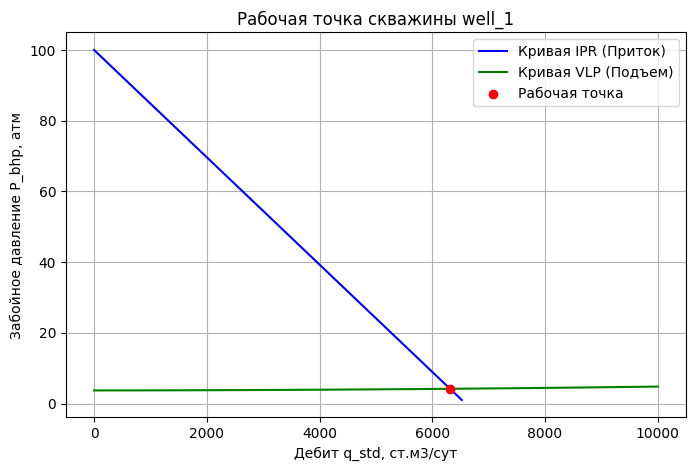

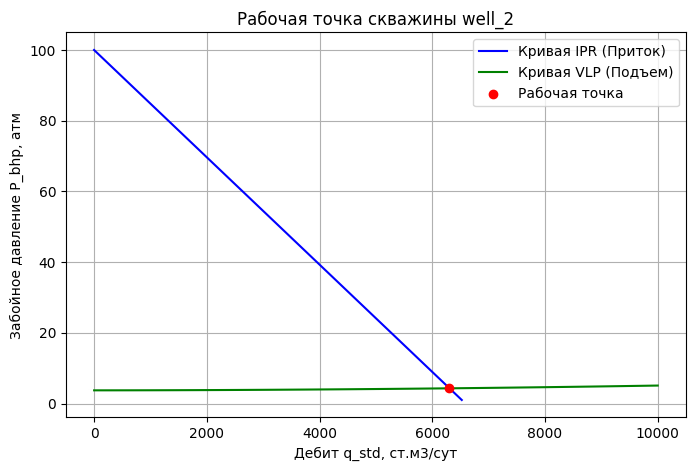

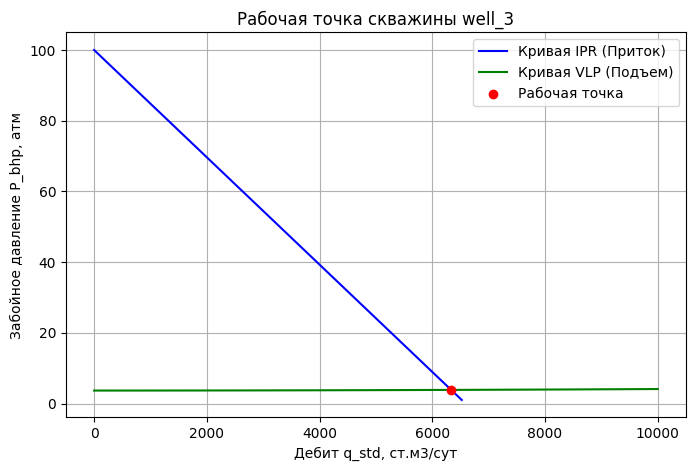

In [47]:
# Инициализация ДКС и Симулятора 
dcs = DCS(CR = 1.5, P_line = 5, q_ext = 500)
simulator = FieldSimulator(reservoir, list([well_1]*3), pipes[:3], pipes[3], dcs)
# Поиск рабочей точки
P_res = simulator.reservoir.resprops.P
sim_states = simulator.solve(P_res)
# Построение графиков для рабочих точек скважин
for i in range(3):
    P_man = sim_states['shlyf'].P_in
    # Кривая притока (IPR)
    P_bhp_ipr = np.linspace(1, P_res, 50)
    q_ipr = [simulator.wells[i].q(P_res, P) for P in P_bhp_ipr]
    # Кривая подъема (VLP)
    q_range = np.linspace(1, 10000, 100)
    P_bhp_vlp = [(P_man + simulator.pipes[i].dP(P_man, q).dP) for q in q_range]
    # Отметка рабочей точки
    q_point = sim_states[f"well_{i+1}"].q_std
    P_bhp_point = P_man + sim_states[f"well_{i+1}"].dP
    
    plt.figure(figsize = (8, 5))
    plt.plot(q_ipr, P_bhp_ipr, label = 'Кривая IPR (Приток)', color = 'blue')
    plt.plot(q_range, P_bhp_vlp, label = 'Кривая VLP (Подъем)', color = 'green')
    plt.scatter(q_point, P_bhp_point, color = 'red', zorder = 5, label = 'Рабочая точка')
    plt.title(f'Рабочая точка cкважины well_{i+1}')
    plt.xlabel('Дебит q_std, ст.м3/сут')
    plt.ylabel('Забойное давление P_bhp, атм')
    plt.grid(True)
    plt.legend()
    
    plt.show()

## 5. Динамика

Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 130/180: P_res = 100.00 атм
Шаг 140/180: P_res = 100.00 атм
Шаг 150/180: P_res = 100.00 атм
Шаг 160/180: P_res = 100.00 атм
Шаг 170/180: P_res = 100.00 атм


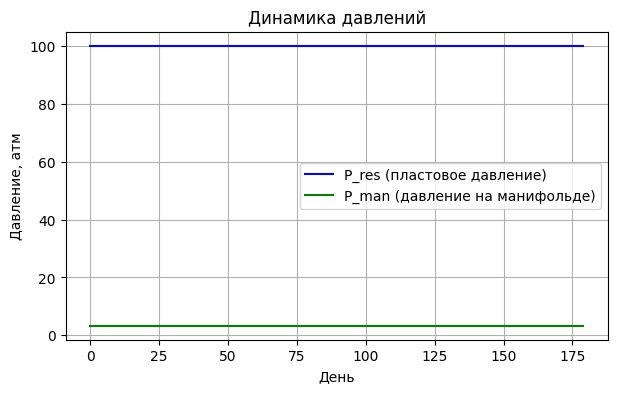

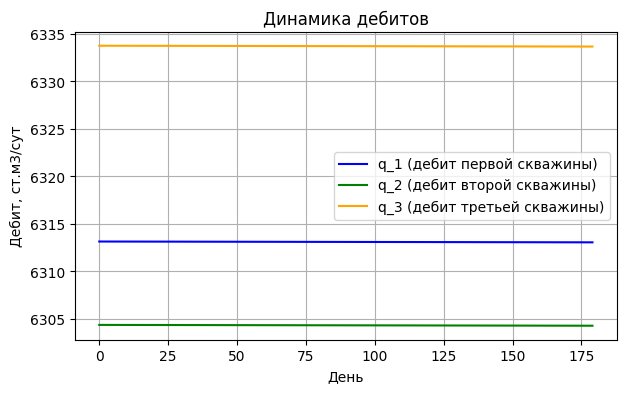

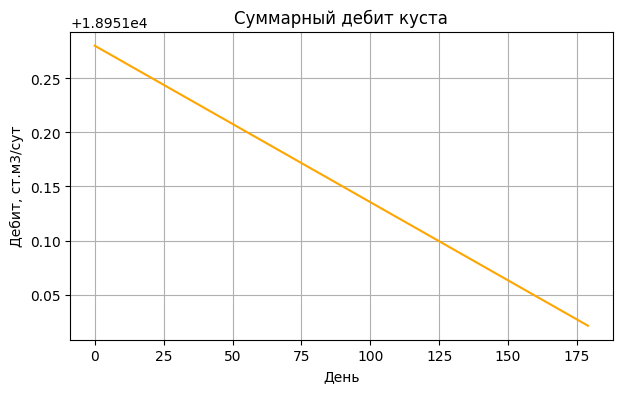

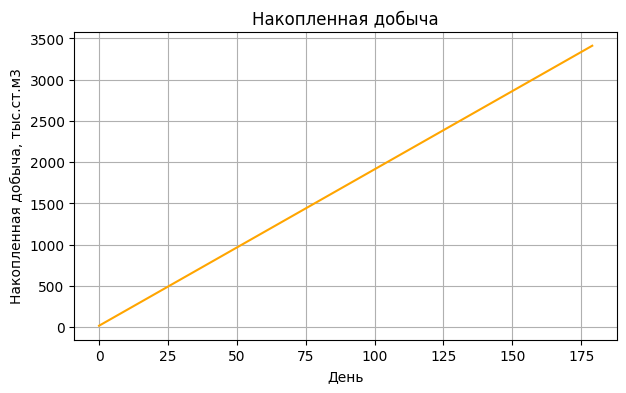

In [48]:
# Запуск динамики на 180 дней 
history = pd.DataFrame(simulator.run(N_days = 180, dt = 1))
# Построение графиков
# График давлений
plt.figure(figsize = (7, 4))
plt.plot(history['day'], history['P_res'], label = 'P_res (пластовое давление)', color = 'blue')
plt.plot(history['day'], history['P_man'], label = 'P_man (давление на манифольде)', color = 'green')
plt.title('Динамика давлений')
plt.xlabel('День')  
plt.ylabel('Давление, атм')
plt.legend()
plt.grid(True)

plt.show()

# График дебитов скважин
plt.figure(figsize = (7, 4))
plt.plot(history['day'], history['q_1'], label = 'q_1 (дебит первой скважины)', color = 'blue')
plt.plot(history['day'], history['q_2'], label = 'q_2 (дебит второй скважины)', color = 'green')
plt.plot(history['day'], history['q_3'], label = 'q_3 (дебит третьей скважины)', color = 'orange')
plt.title('Динамика дебитов')
plt.xlabel('День')  
plt.ylabel('Дебит, ст.м3/сут')
plt.legend()
plt.grid(True)

plt.show()

# График суммарного дебита
plt.figure(figsize = (7, 4))
plt.plot(history['day'], history['q_total'], color = 'orange')
plt.title('Суммарный дебит куста')
plt.xlabel('День')
plt.ylabel('Дебит, ст.м3/сут')
plt.grid(True)

plt.show()

# График накопленной добычи
plt.figure(figsize = (7, 4))
plt.plot(history['day'], history['gp'], color = 'orange')
plt.title('Накопленная добыча')
plt.xlabel('День')
plt.ylabel('Накопленная добыча, тыс.ст.м3')
plt.grid(True)

plt.show()

## 6. Влияние ДКС

При CR = 1
Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 130/180: P_res = 100.00 атм
Шаг 140/180: P_res = 100.00 атм
Шаг 150/180: P_res = 100.00 атм
Шаг 160/180: P_res = 100.00 атм
Шаг 170/180: P_res = 100.00 атм
При CR = 1.5
Шаг 0/180: P_res = 100.00 атм
Шаг 10/180: P_res = 100.00 атм
Шаг 20/180: P_res = 100.00 атм
Шаг 30/180: P_res = 100.00 атм
Шаг 40/180: P_res = 100.00 атм
Шаг 50/180: P_res = 100.00 атм
Шаг 60/180: P_res = 100.00 атм
Шаг 70/180: P_res = 100.00 атм
Шаг 80/180: P_res = 100.00 атм
Шаг 90/180: P_res = 100.00 атм
Шаг 100/180: P_res = 100.00 атм
Шаг 110/180: P_res = 100.00 атм
Шаг 120/180: P_res = 100.00 атм
Шаг 13

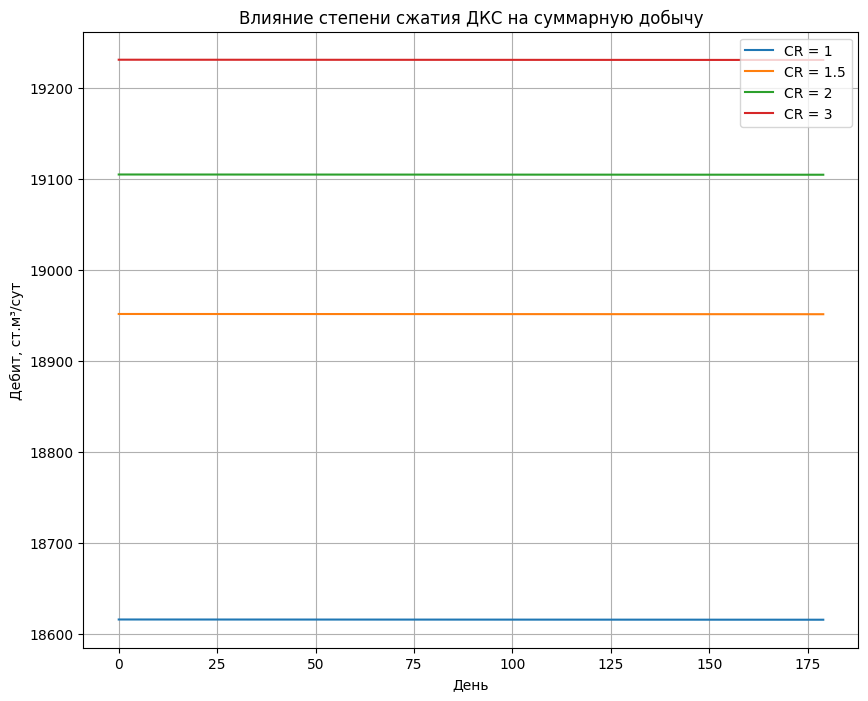

In [49]:
# Сравнение динамики при CR = 1, 1.5, 2, 3
CR_range = [1, 1.5, 2, 3]

plt.figure(figsize = (10, 8))
for i in range(4):
    reservoir.resprops.P = 100
    dcs.CR = CR_range[i]
    # Инициализируем симулятор с новым значением CR
    sim_CR = FieldSimulator(reservoir, list([well_1]*3), pipes[:3], pipes[3], dcs)
    print(f"При CR = {CR_range[i]}")
    history_CR = pd.DataFrame(sim_CR.run(N_days = 180, dt = 1))
    # Строим кривую
    plt.plot(history_CR['day'], history_CR['q_total'], label = f'CR = {CR_range[i]}')
plt.title('Влияние степени сжатия ДКС на суммарную добычу')
plt.xlabel('День')
plt.ylabel('Дебит, ст.м³/сут')
plt.legend()
plt.grid(True, which = "both", ls = "-") 

plt.show()

## 7. Калибровка

Оптимальный коэффициент C: 23230.26
Минимальный RMSE: 2499.69 ст.м3/сут
Коэффициент детерминации R2: 0.9709


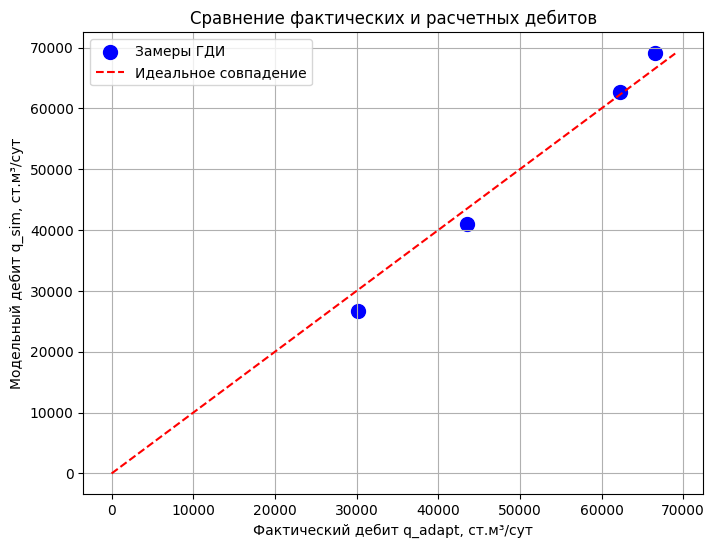

In [50]:
# Загрузка данных калибровки
adapt_data = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')
# Выделим фактические данные для удобства
q_adapt = adapt_data['q'].values
P_res_adapt = adapt_data['p_res'].values
P_bhp_adapt = adapt_data['p_bhp'].values
# Определение целевой функции RMSE
def RMSE(C):
    # Расчет модельных дебитов для каждого замера
    q = C * (P_res_adapt - P_bhp_adapt)
    # Расчет RMSE по формуле из ТЗ
    rmse = math.sqrt(np.mean((q - q_adapt)**2))
    return rmse
# Минимизация ошибки для поиска оптимального C
res_opt = minimize(RMSE, x0 = [1000.0], method = 'Nelder-Mead')
C_opt = res_opt.x[0]
# Расчет метрик качества
q_sim = C_opt * (P_res_adapt - P_bhp_adapt)
# Расчёт метрики RMSE
RMSE_final = res_opt.fun
# Расчет метрики R2
R2_final = 1 - (np.sum((q_adapt - q_sim)**2) / np.sum((q_adapt - np.mean(q_adapt))**2))
print(f"Оптимальный коэффициент C: {C_opt:.2f}")
print(f"Минимальный RMSE: {RMSE_final:.2f} ст.м3/сут")
print(f"Коэффициент детерминации R2: {R2_final:.4f}")
# Визуализация «Факт vs Модель»
plt.figure(figsize = (8, 6))
plt.scatter(q_adapt, q_sim, color = 'blue', label = 'Замеры ГДИ', s = 100)
# Линия идеального совпадения
max_q = max(q_adapt.max(), q_sim.max())
plt.plot([0, max_q], [0, max_q], '--', color = 'red', label = 'Идеальное совпадение')
plt.title('Сравнение фактических и расчетных дебитов')
plt.xlabel('Фактический дебит q_adapt, ст.м³/сут')
plt.ylabel('Модельный дебит q_sim, ст.м³/сут')
plt.legend()
plt.grid(True)

plt.show()